### CLASSIFICATION DES IMAGES PAR CLASSES ET SOUS-CLASSES

In [2]:
#Importration des librairies . 
from sklearn import datasets 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as sc
from sklearn.model_selection import train_test_split
import random
from sklearn.neural_network import MLPClassifier as MLPC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score





#### 1ère partie : Classification un modèle de machine learning sur les caractéristiques extraites.

In [3]:
#Imortation du dataset. 

Xdf = pd.read_csv("database.csv") 

#On visualise la structure du dataset
n,p = Xdf.shape
print(f"Taille du dataset : ({n}, {p})\n")
Xdf.head()


Taille du dataset : (2688, 30)



,Numero,Classe,SousClasse,GaborFeature0,GaborFeature1,GaborFeature2,GaborFeature3,GaborFeature4,GaborFeature5,GaborFeature6,...,GaborFeature17,GaborFeature18,GaborFeature19,GaborFeature20,GaborFeature21,GaborFeature22,GaborFeature23,Y_Feature,Cr_Feature,Cb_Feature
0,1927,NATUREL,OPEN_COUNTRY,-0.534358,-0.525756,-0.569507,-0.526244,-0.758949,-0.777145,-0.655355,...,-0.245392,-0.350766,-0.139132,-0.638998,-0.593121,-0.531703,-0.231393,0.468970,0.848787,-2.490682
1,2076,ARTIFICIEL,RUE,0.111617,0.225386,0.719857,0.509317,1.327478,1.404515,0.396153,...,1.359529,0.792866,0.670435,0.818410,0.837560,0.535152,0.098582,0.135082,0.527263,-0.477937
2,1012,ARTIFICIEL,VILLE,-0.175443,-0.052435,0.877849,0.067135,0.396117,0.129128,1.834266,...,0.728218,0.369247,0.001506,-0.286736,0.401835,0.802573,0.158772,-0.822426,0.127975,0.144827
3,2069,ARTIFICIEL,RUE,-0.239083,0.130569,0.201182,0.221323,0.263732,0.827890,1.515108,...,2.133495,0.701045,0.373932,0.242101,0.413113,0.288646,0.403911,0.764572,-0.459236,0.106642
4,951,ARTIFICIEL,VILLE,0.670929,0.289145,0.246102,-0.200038,0.892492,-0.377802,-0.475454,...,-0.527731,-0.631941,-0.305346,0.424133,-0.365025,-0.489855,-0.428821,1.020113,-1.272951,1.255535


On remarque que notre dataset est constitué de 2688 lignes et de 30 colonnes, la première représente le numéro de l'image les 2 suivantes sont respectivement les classes et sous-classes de chaque image et
les 27 suivantes (de la 4 à la 30e) représentent les caractéristiques



In [4]:
Xdf.dtypes


Numero              int64
Classe             object
SousClasse         object
GaborFeature0     float64
GaborFeature1     float64
GaborFeature2     float64
GaborFeature3     float64
GaborFeature4     float64
GaborFeature5     float64
GaborFeature6     float64
GaborFeature7     float64
GaborFeature8     float64
GaborFeature9     float64
GaborFeature10    float64
GaborFeature11    float64
GaborFeature12    float64
GaborFeature13    float64
GaborFeature14    float64
GaborFeature15    float64
GaborFeature16    float64
GaborFeature17    float64
GaborFeature18    float64
GaborFeature19    float64
GaborFeature20    float64
GaborFeature21    float64
GaborFeature22    float64
GaborFeature23    float64
Y_Feature         float64
Cr_Feature        float64
Cb_Feature        float64
dtype: object

In [5]:
Xdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688 entries, 0 to 2687
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Numero          2688 non-null   int64  
 1   Classe          2688 non-null   object 
 2   SousClasse      2688 non-null   object 
 3   GaborFeature0   2688 non-null   float64
 4   GaborFeature1   2688 non-null   float64
 5   GaborFeature2   2688 non-null   float64
 6   GaborFeature3   2688 non-null   float64
 7   GaborFeature4   2688 non-null   float64
 8   GaborFeature5   2688 non-null   float64
 9   GaborFeature6   2688 non-null   float64
 10  GaborFeature7   2688 non-null   float64
 11  GaborFeature8   2688 non-null   float64
 12  GaborFeature9   2688 non-null   float64
 13  GaborFeature10  2688 non-null   float64
 14  GaborFeature11  2688 non-null   float64
 15  GaborFeature12  2688 non-null   float64
 16  GaborFeature13  2688 non-null   float64
 17  GaborFeature14  2688 non-null   f

In [6]:
Xdf.describe()

,Numero,GaborFeature0,GaborFeature1,GaborFeature2,GaborFeature3,GaborFeature4,GaborFeature5,GaborFeature6,GaborFeature7,GaborFeature8,...,GaborFeature17,GaborFeature18,GaborFeature19,GaborFeature20,GaborFeature21,GaborFeature22,GaborFeature23,Y_Feature,Cr_Feature,Cb_Feature
count,2688.000000,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,...,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03,2.688000e+03
mean,1343.500000,1.850372e-17,7.004979e-17,1.321694e-17,1.004487e-16,-1.206046e-17,4.229421e-17,-8.987520e-17,3.965082e-17,1.453863e-17,...,2.312965e-17,-1.169699e-16,-8.723181e-17,5.286776e-17,-1.050747e-16,1.982541e-18,-6.872809e-17,2.511219e-17,1.956107e-16,-4.282289e-16
std,776.103086,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,...,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00
min,0.000000,-5.507909e-01,-5.507426e-01,-6.685841e-01,-7.358574e-01,-9.051396e-01,-9.724596e-01,-9.628479e-01,-8.754606e-01,-8.467024e-01,...,-9.067962e-01,-8.892949e-01,-8.979148e-01,-8.561555e-01,-8.308871e-01,-9.119378e-01,-8.833166e-01,-2.941101e+00,-4.540489e+00,-4.839633e+00
25%,671.750000,-4.945687e-01,-4.913480e-01,-5.779625e-01,-6.146567e-01,-6.771426e-01,-6.981778e-01,-6.636477e-01,-6.276447e-01,-5.660138e-01,...,-5.969946e-01,-5.806993e-01,-6.036092e-01,-6.387780e-01,-5.934916e-01,-6.438069e-01,-6.374225e-01,-6.349965e-01,-5.938265e-01,-5.175380e-01
50%,1343.500000,-3.604874e-01,-3.244246e-01,-3.408673e-01,-3.303246e-01,-3.185775e-01,-3.041918e-01,-2.904148e-01,-3.020918e-01,-3.060493e-01,...,-2.727703e-01,-2.763170e-01,-2.935209e-01,-3.289518e-01,-2.851326e-01,-2.968150e-01,-3.027789e-01,5.921503e-02,-1.789951e-02,4.175597e-02
75%,2015.250000,7.276819e-02,9.053203e-02,1.870731e-01,2.169256e-01,3.173186e-01,3.718199e-01,3.814867e-01,2.629260e-01,1.779027e-01,...,2.460474e-01,2.325573e-01,2.009202e-01,2.796222e-01,2.977321e-01,3.293230e-01,2.727309e-01,6.211426e-01,5.572163e-01,6.385948e-01
max,2687.000000,1.434079e+01,2.069380e+01,1.271028e+01,9.979707e+00,9.893661e+00,8.248066e+00,1.105859e+01,9.588065e+00,1.208070e+01,...,1.174286e+01,1.209896e+01,9.955945e+00,1.098245e+01,2.285846e+01,1.154647e+01,1.054416e+01,3.758650e+00,5.770646e+00,4.162559e+00


Chaque feature est du type float ( variable quantitaitve) la classe et la sous-classe sont des object (texte non encodé) tandis que le numéro est un entier entre 0 et 2687 et le dataset ne présente pas de valeur manquante

In [7]:
# Séparation des features du dataset et des colonnes cibles
Xdf["Group1"] = Xdf["SousClasse"].astype("category")
Xdf["Group2"] = Xdf["Classe"].astype("category")

Xdf_numeric = Xdf.iloc[:,1:].select_dtypes(include="number") #En excluant la colonne numéro
y_sous_classe = Xdf["Group1"]
y_classe = Xdf["Group2"]

##### Analyse descriptive

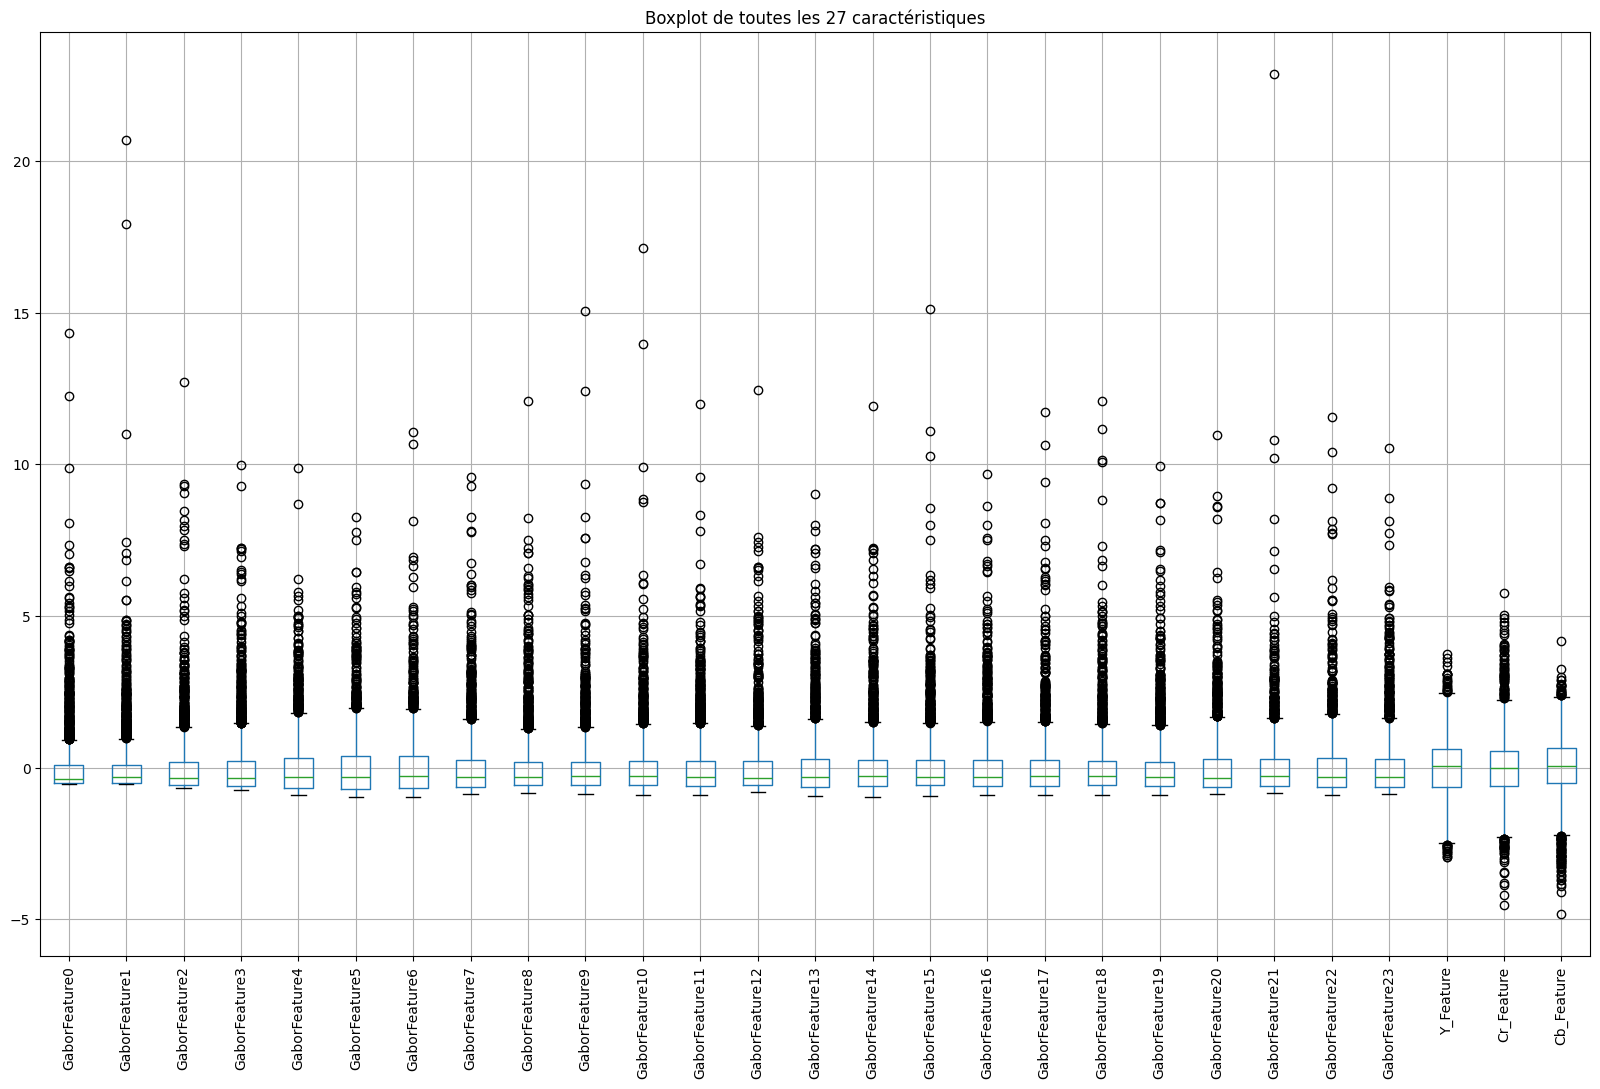

In [8]:

#Tracer des boxplot 
plt.figure(figsize=(20, 12)) # Ajuste la taille pour 27 features
Xdf_numeric.boxplot()

# 4. Améliorer la lisibilité
plt.title('Boxplot de toutes les 27 caractéristiques')
plt.xticks(rotation=90) # Fait pivoter les noms des features
plt.show()

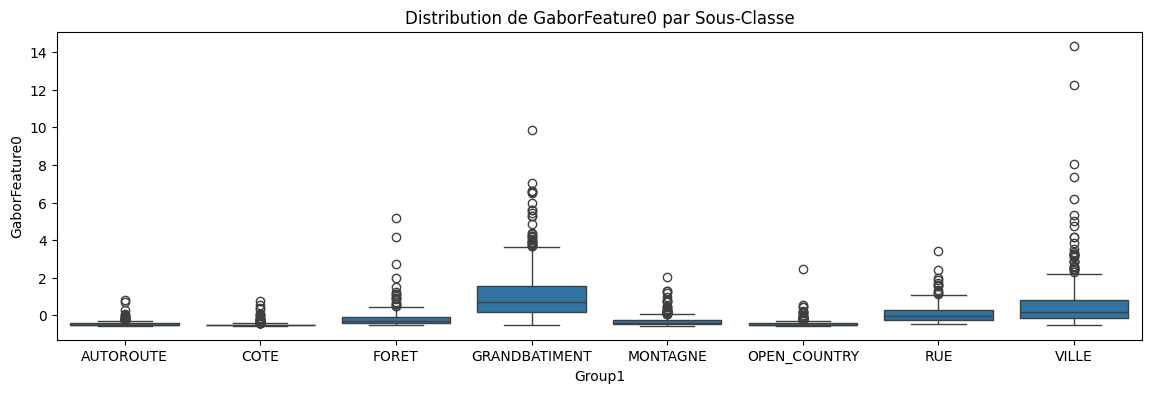

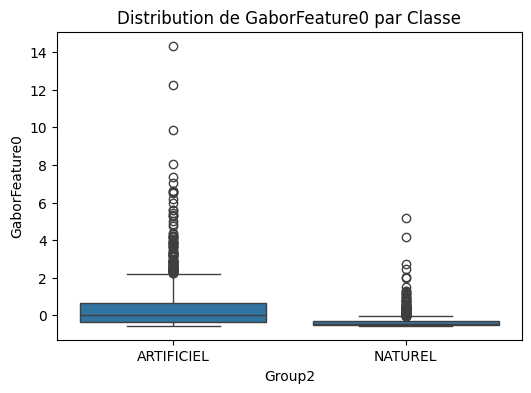

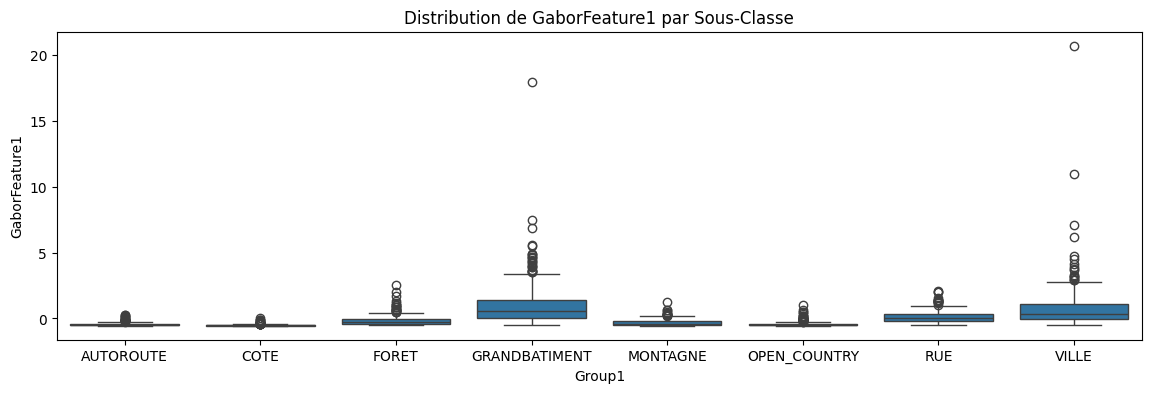

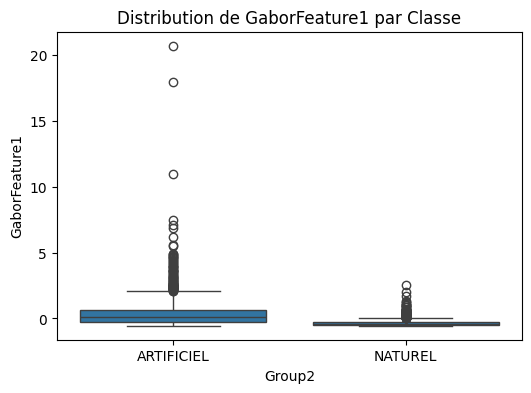

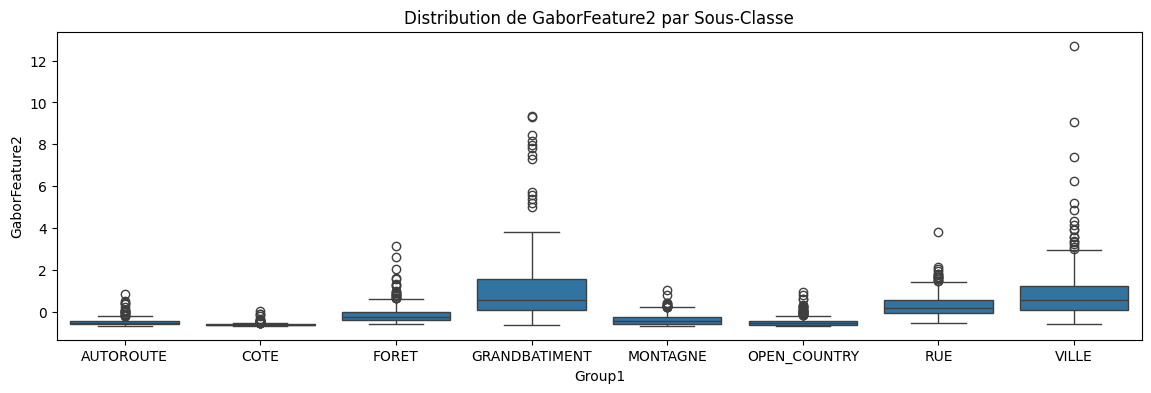

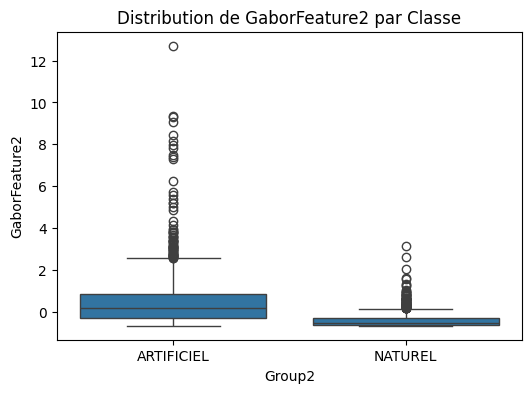

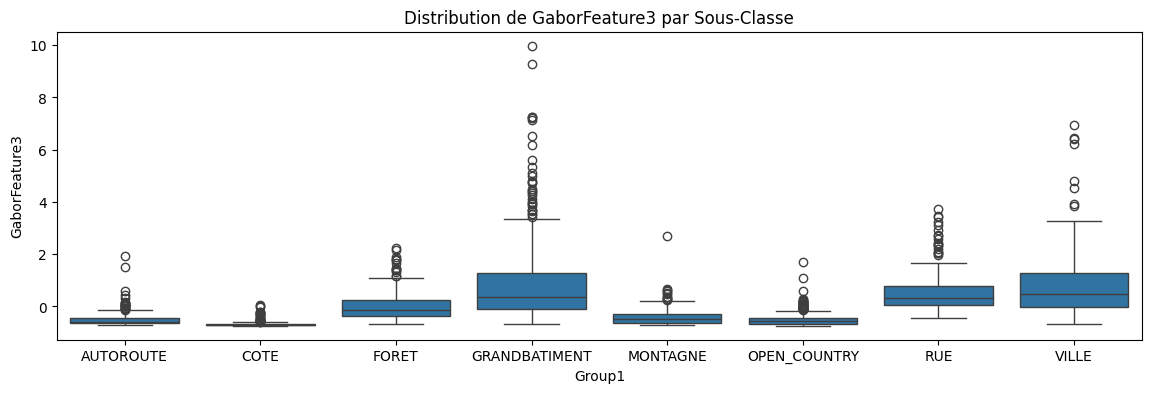

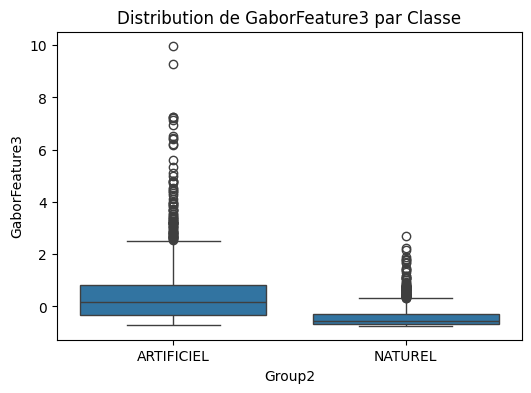

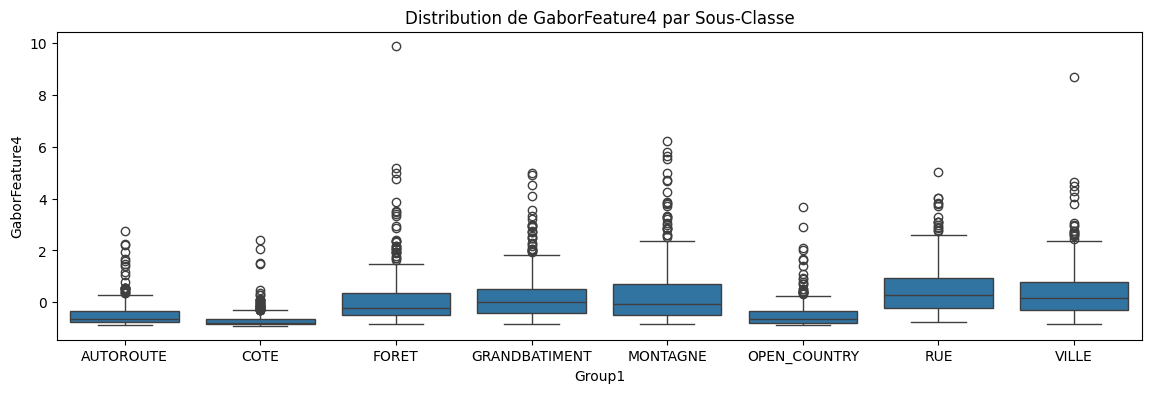

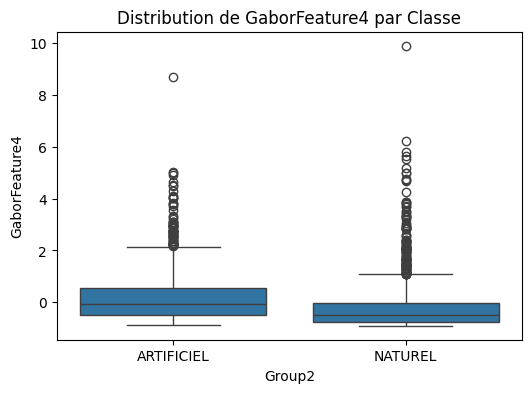

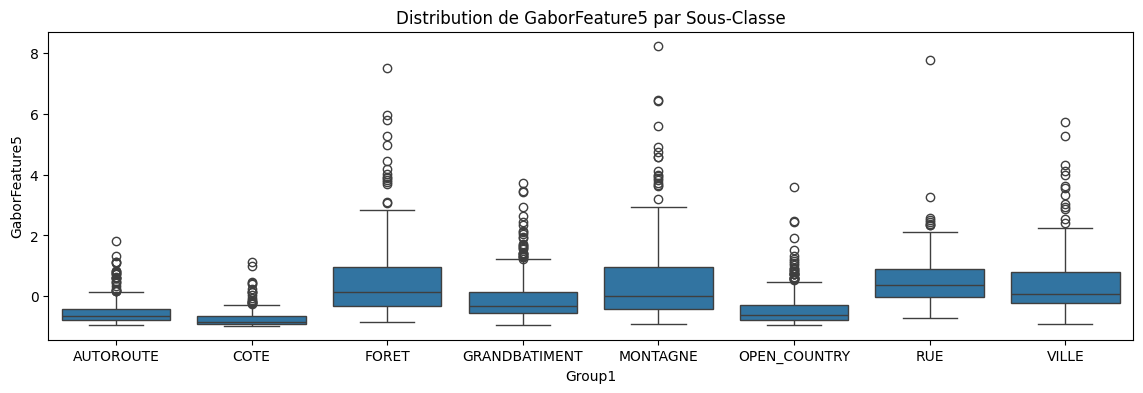

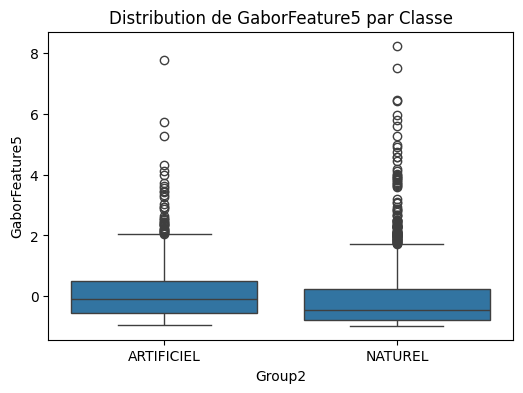

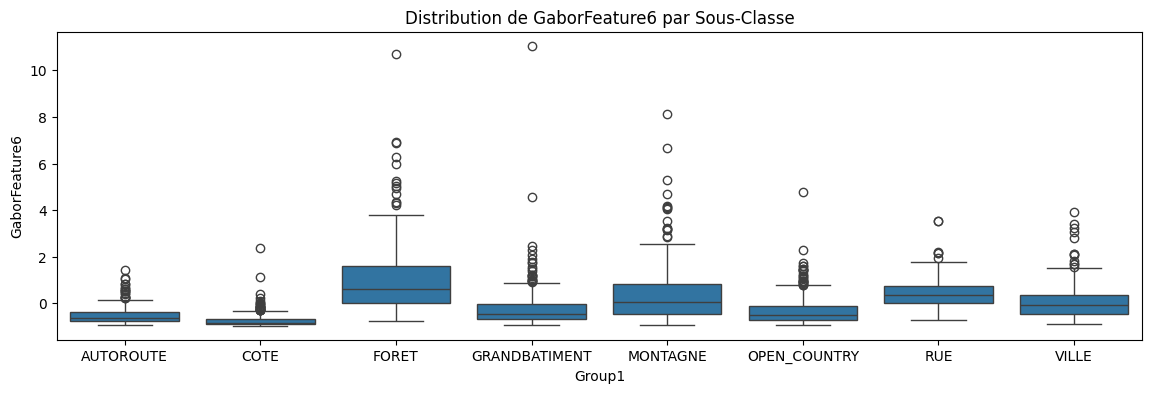

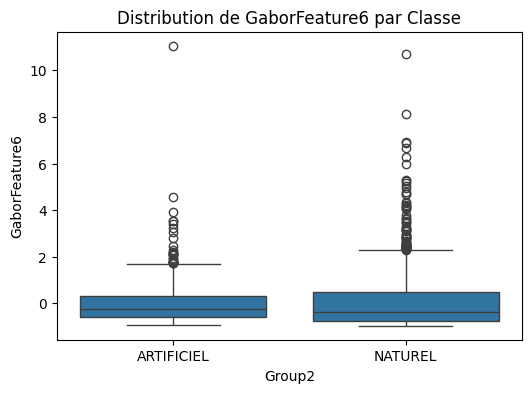

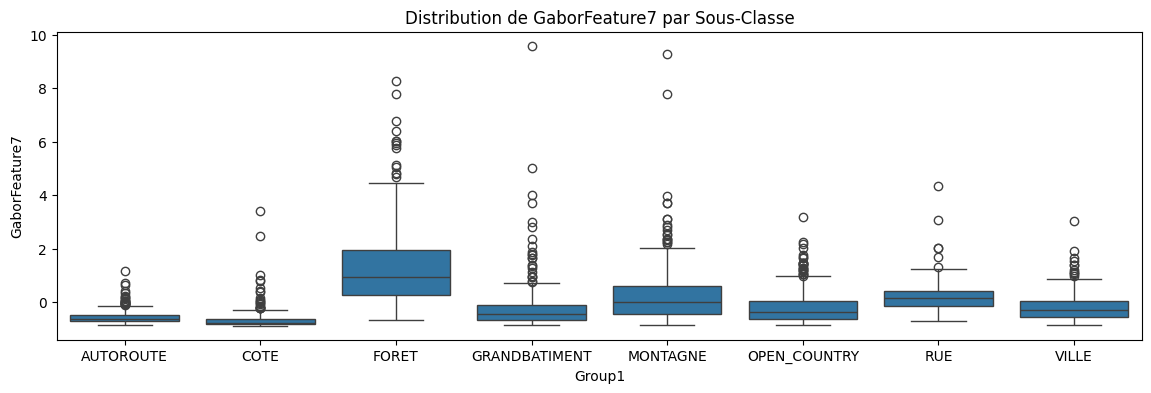

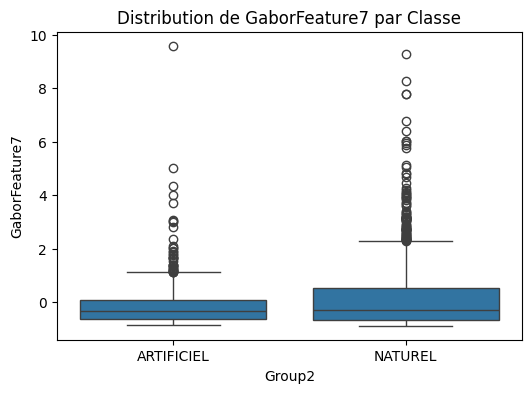

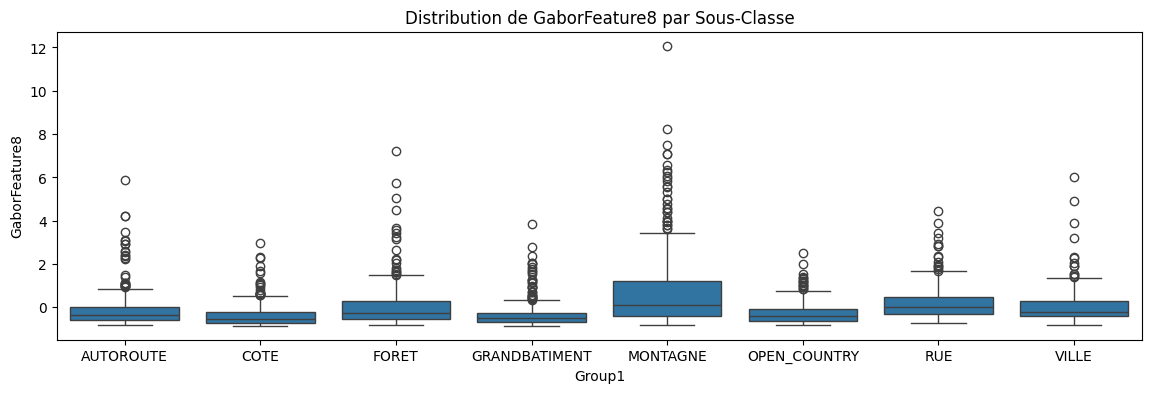

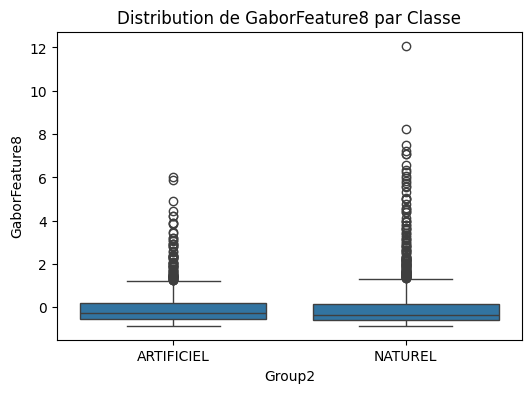

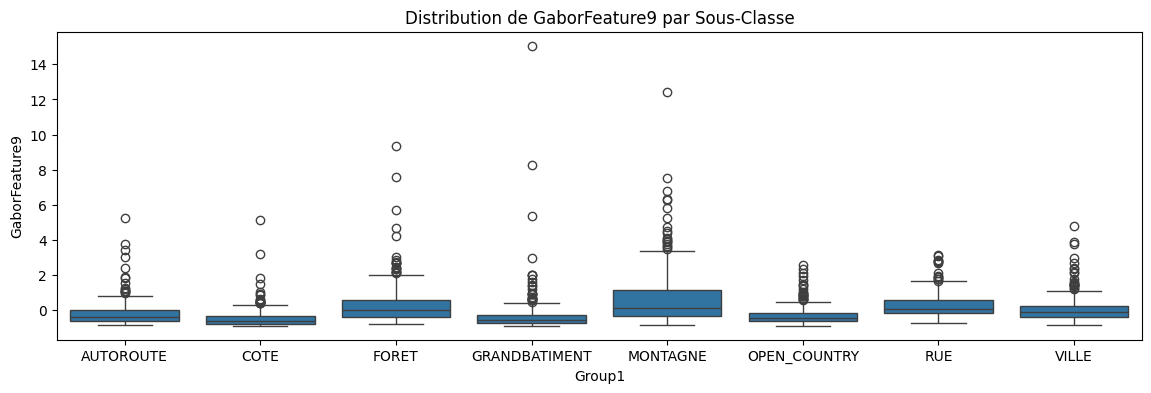

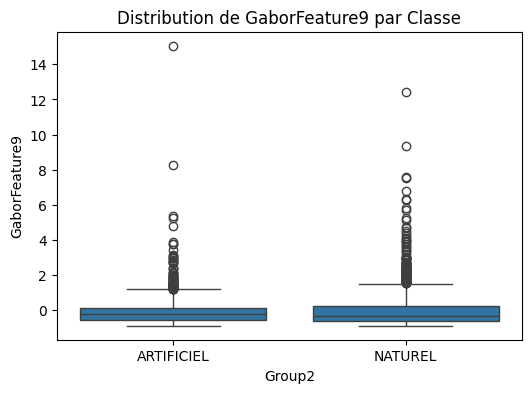

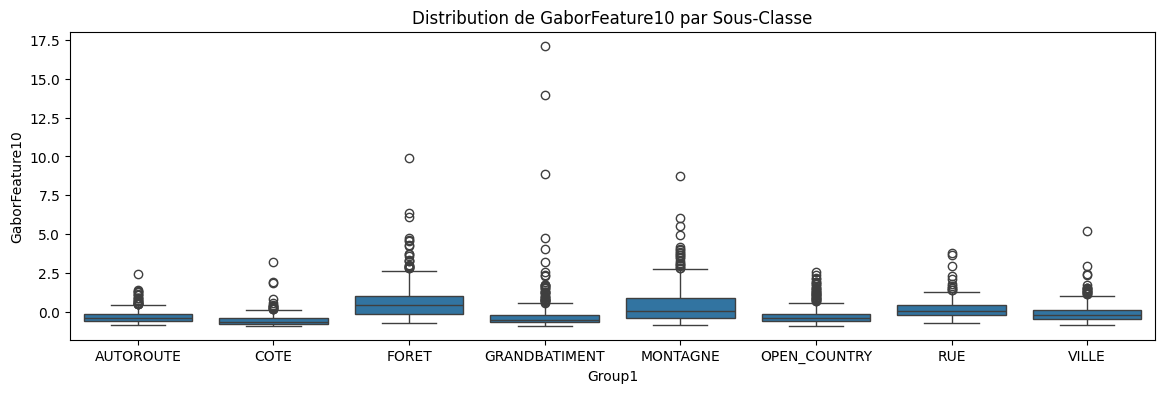

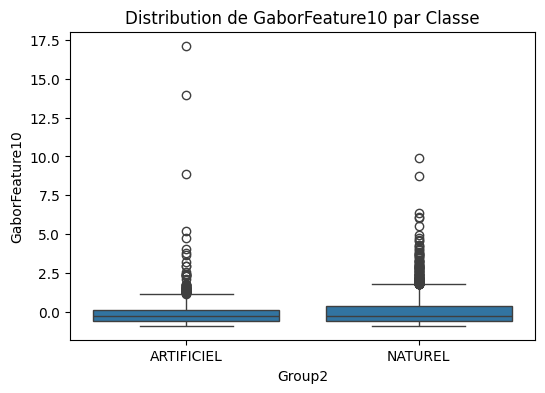

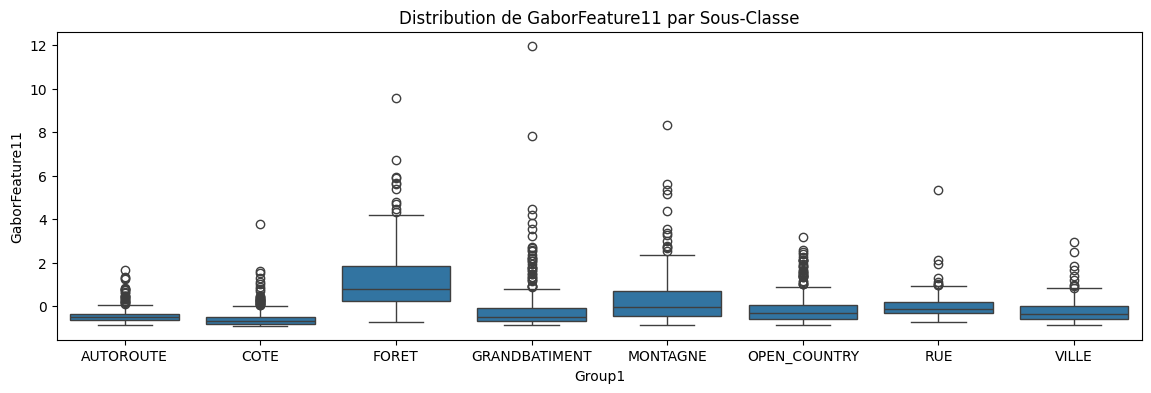

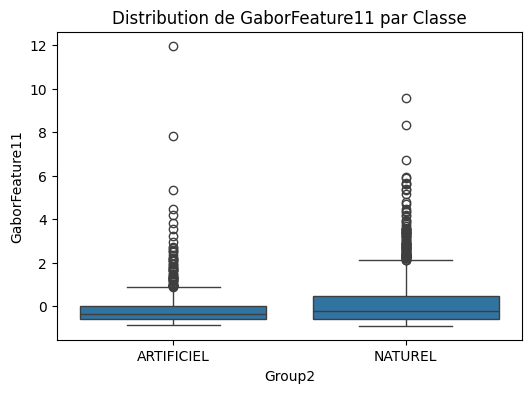

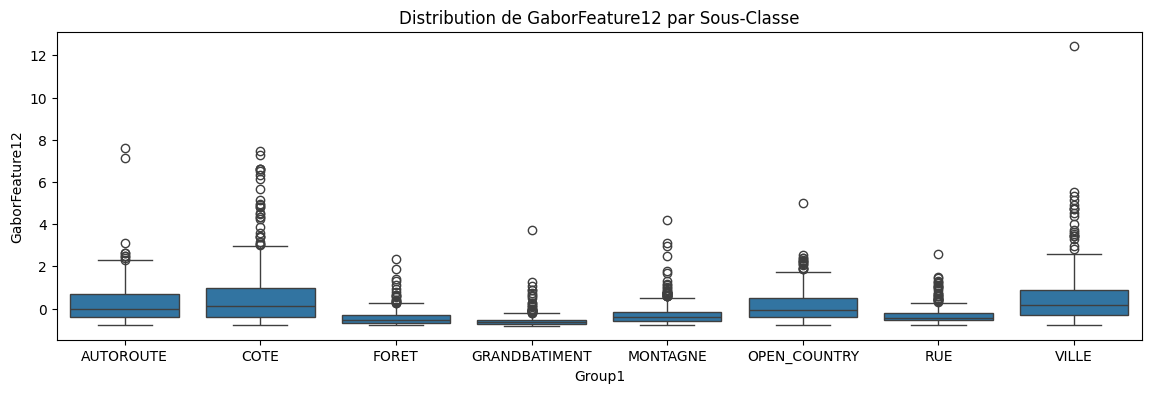

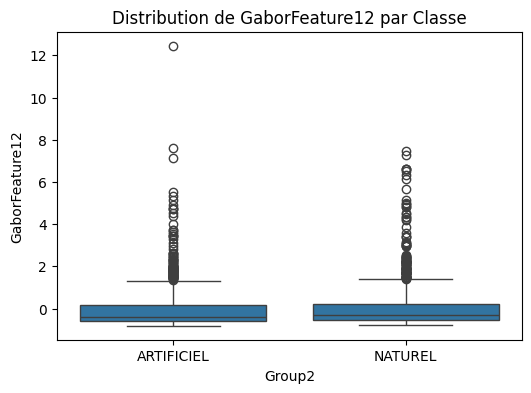

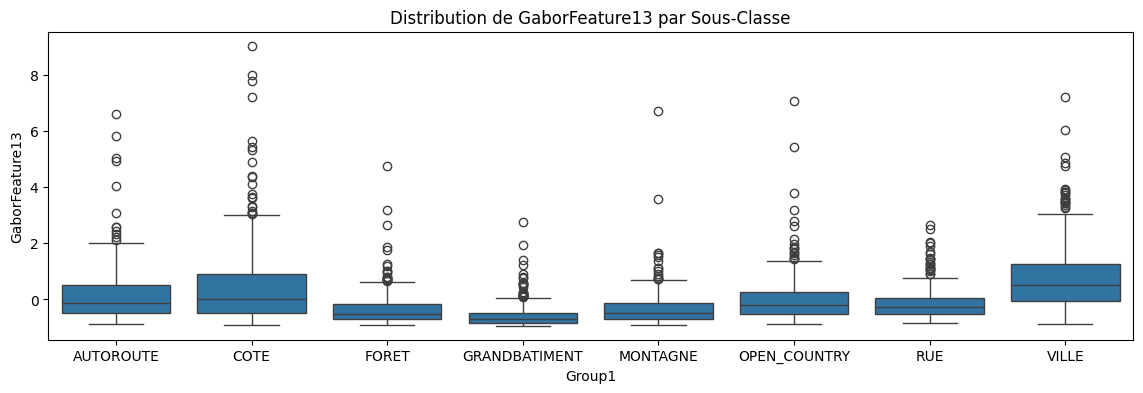

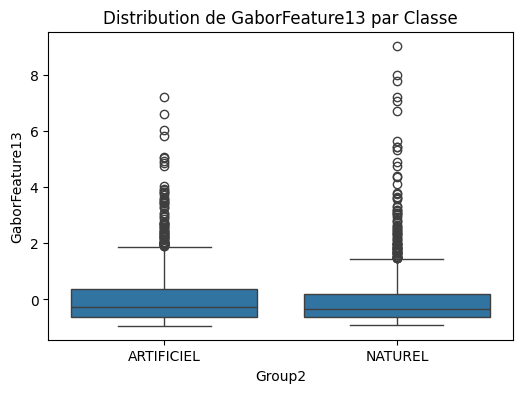

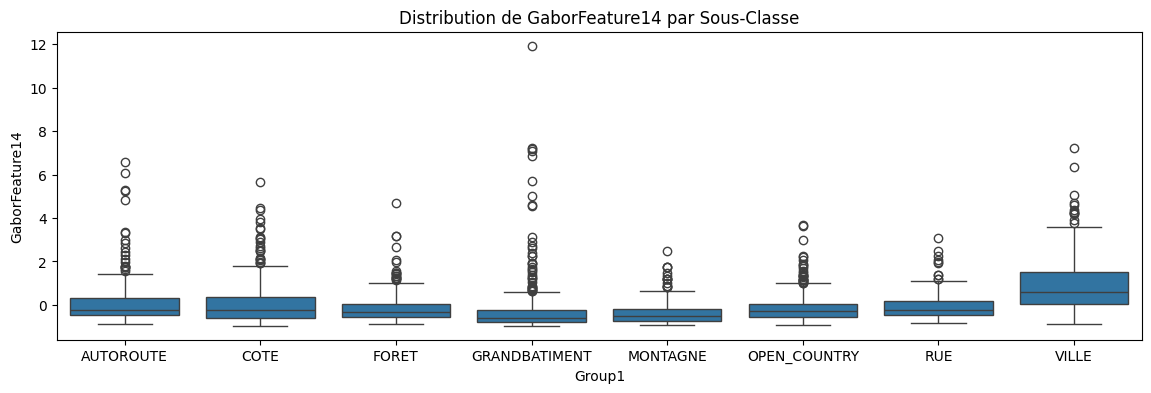

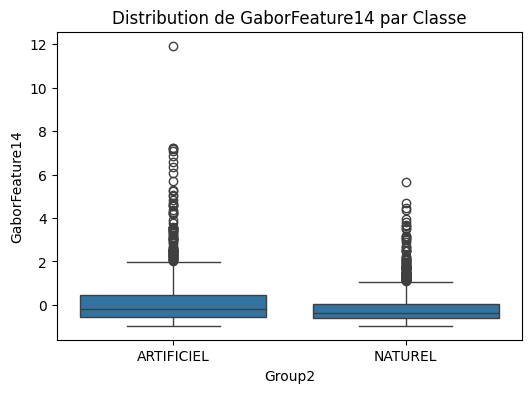

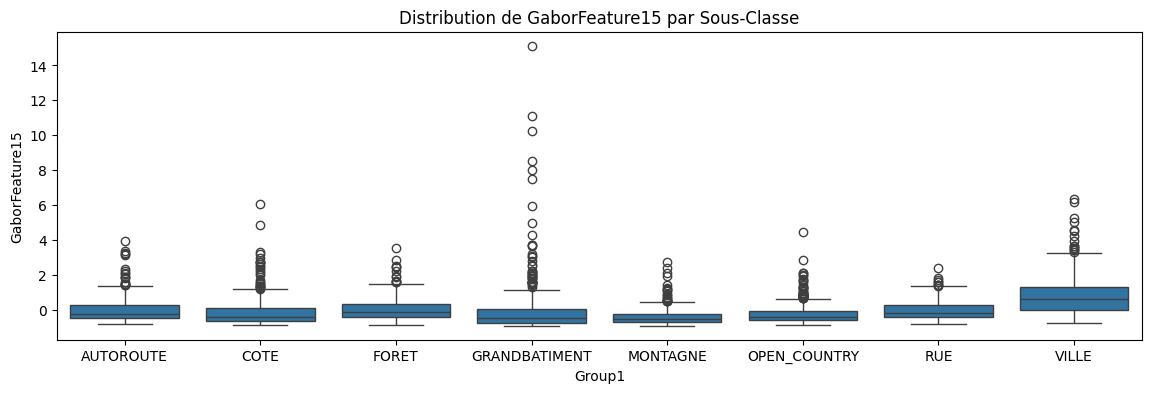

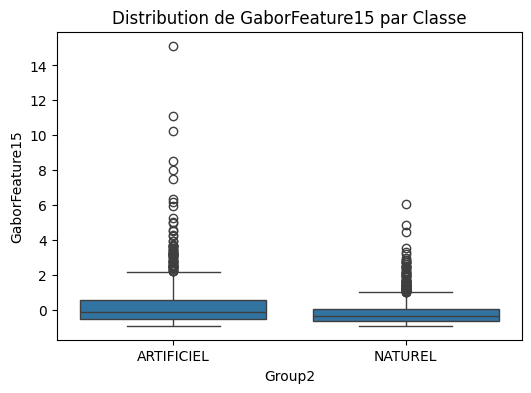

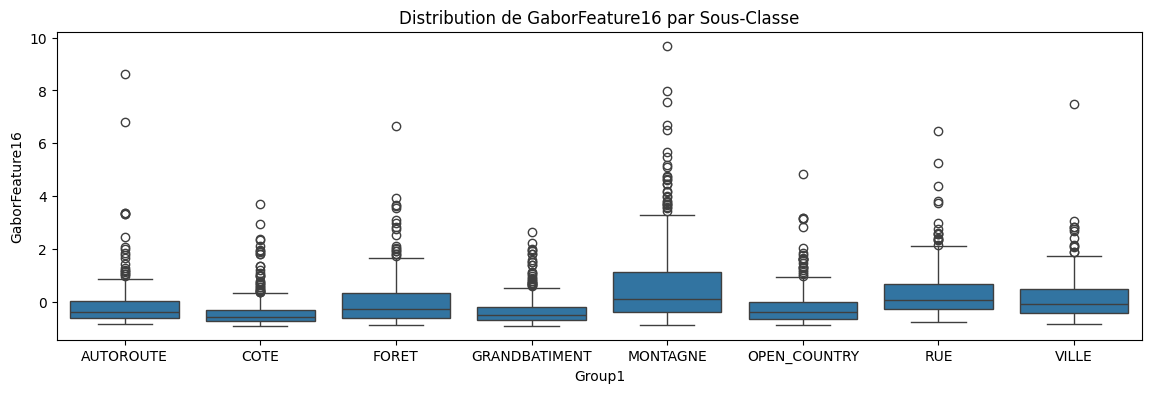

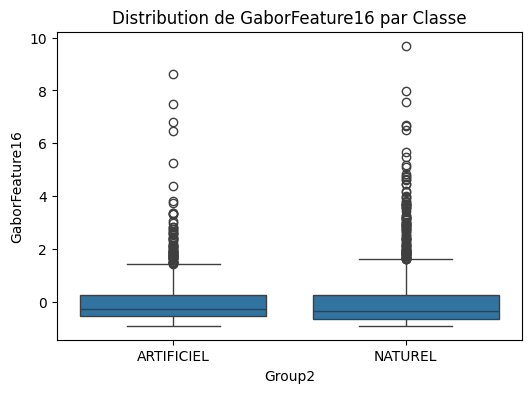

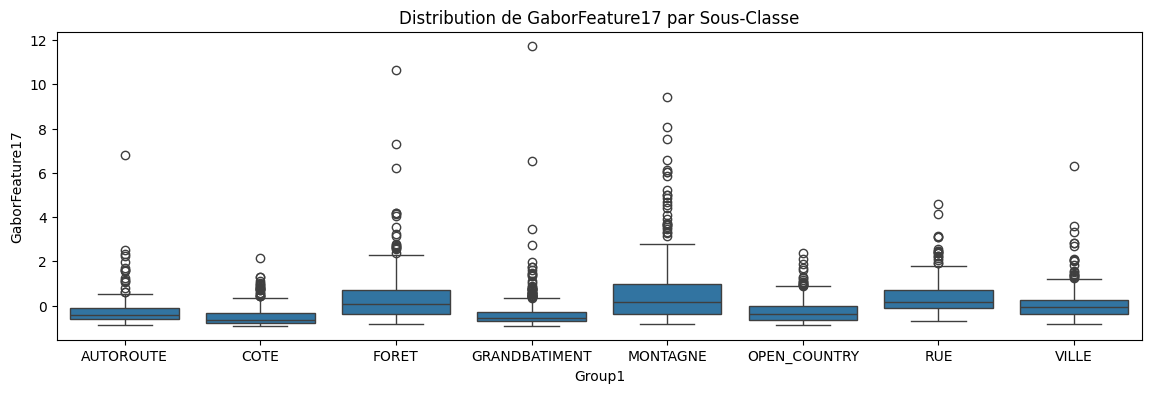

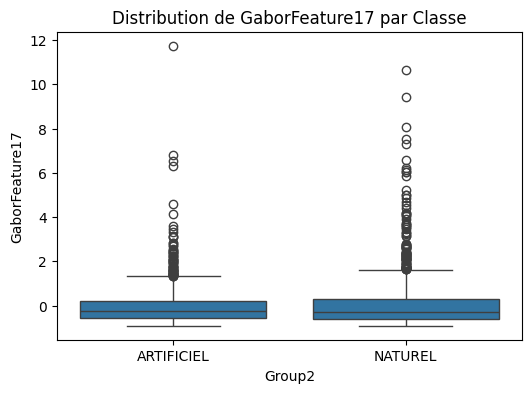

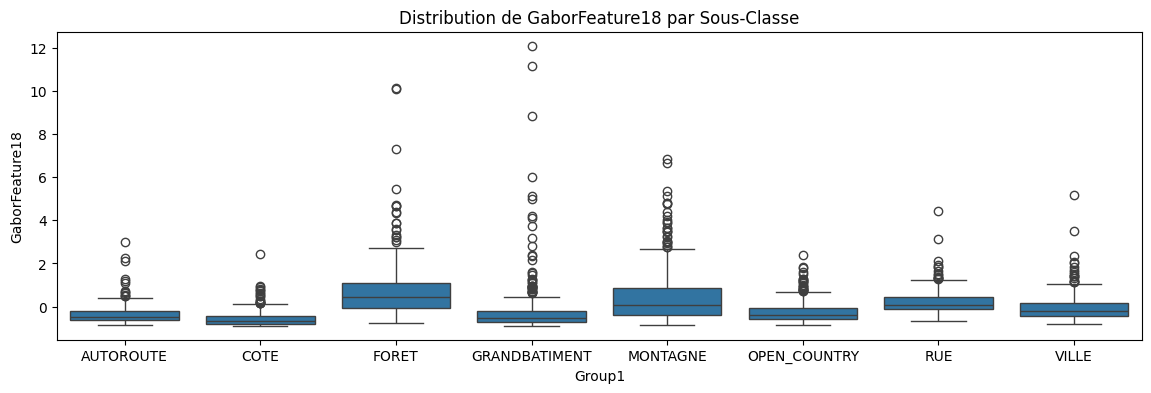

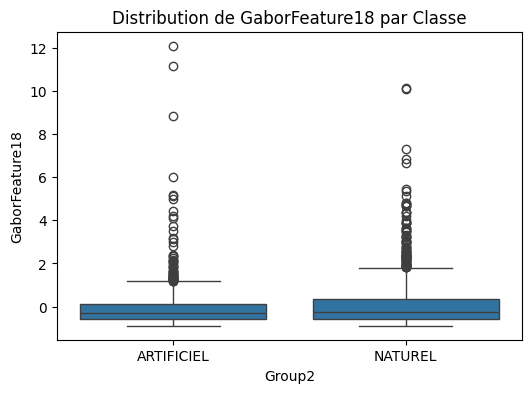

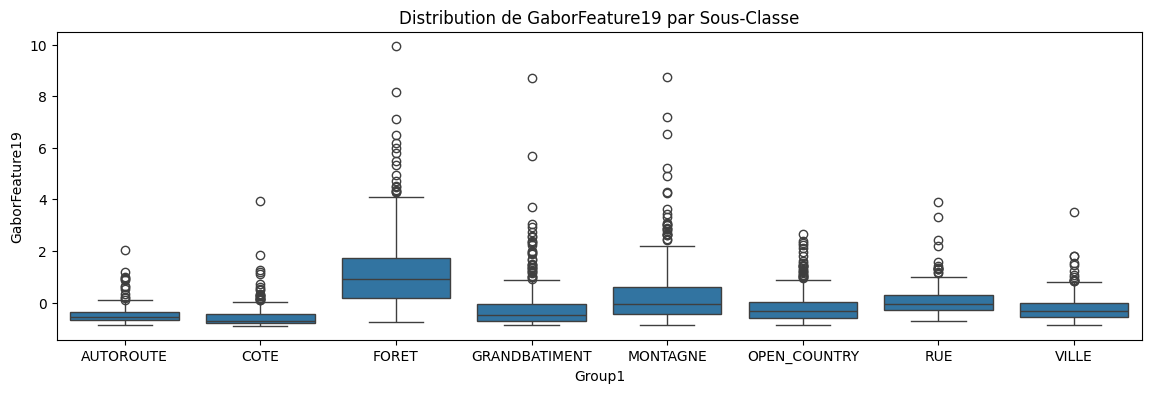

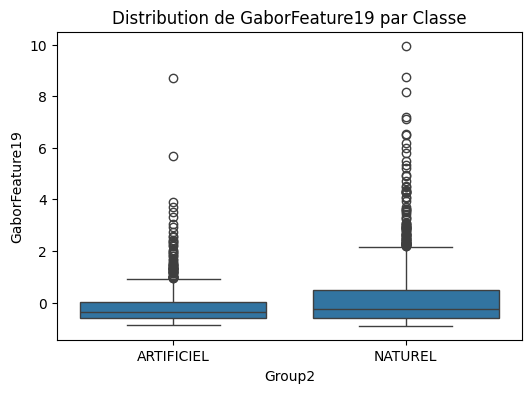

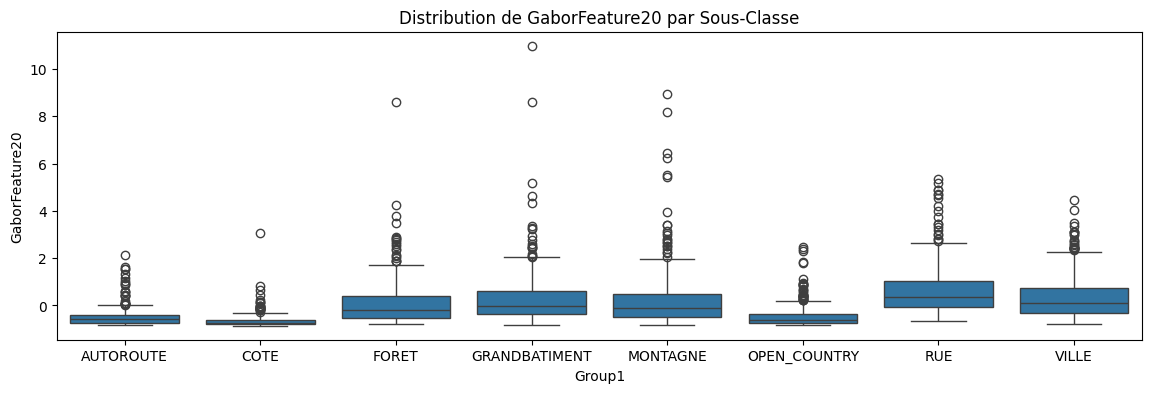

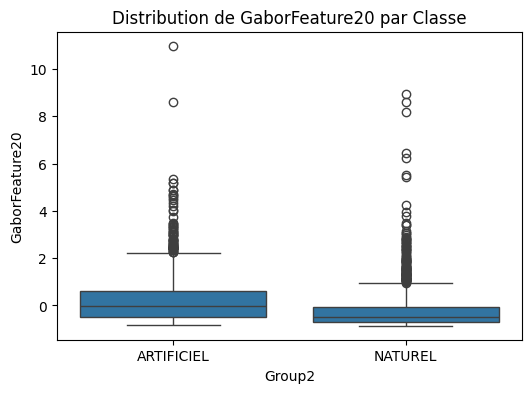

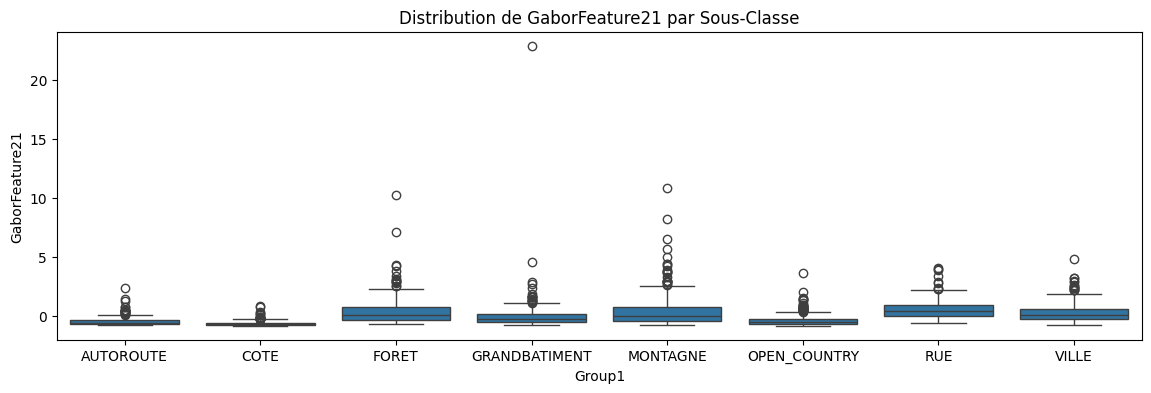

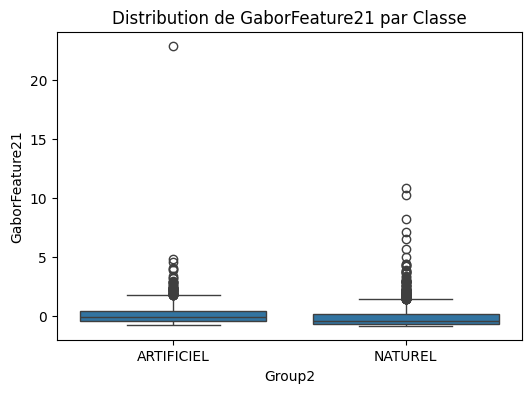

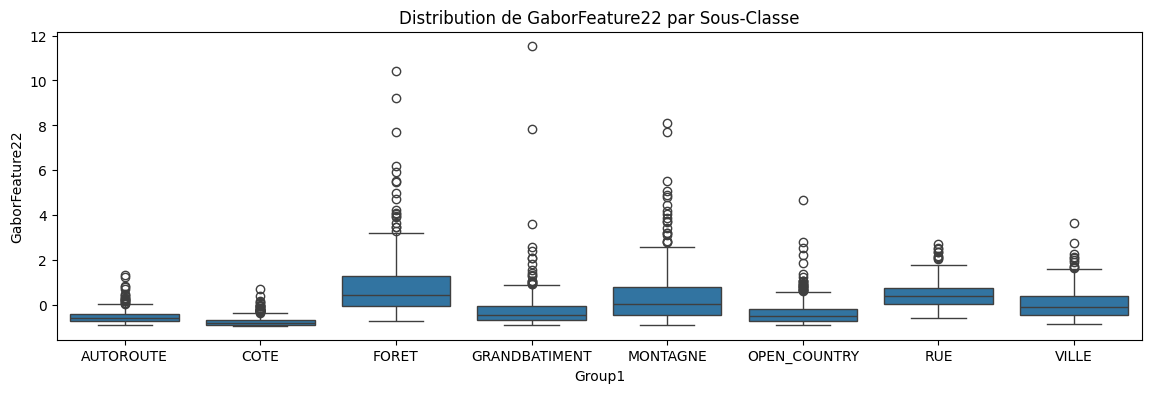

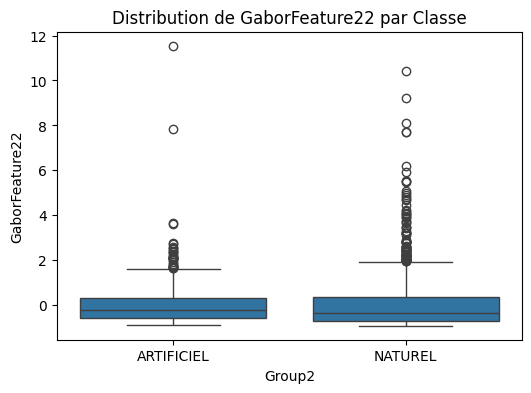

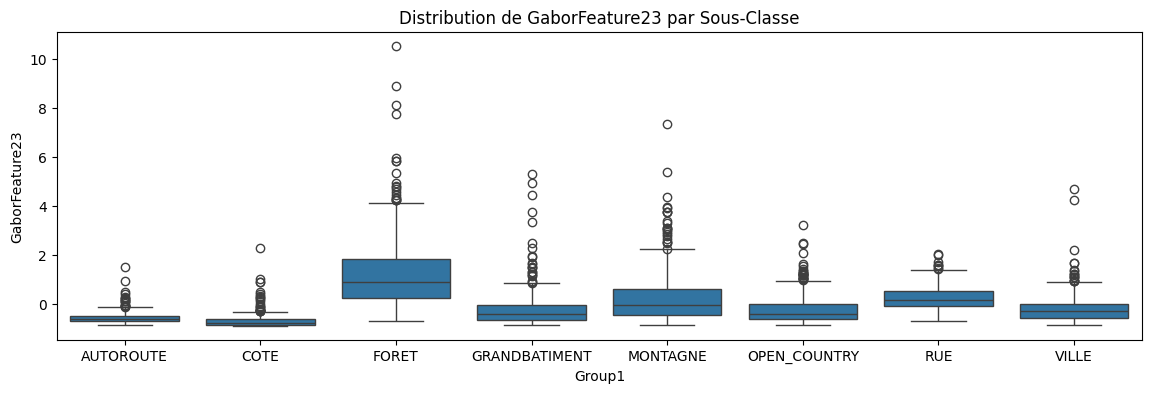

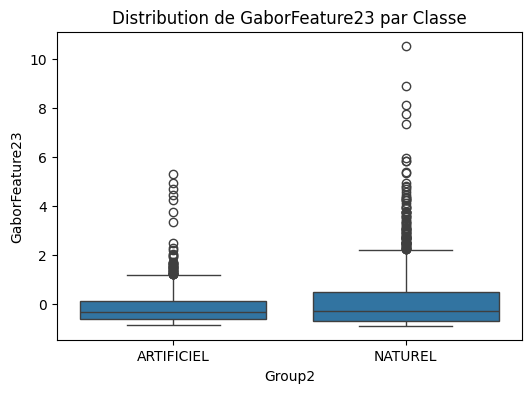

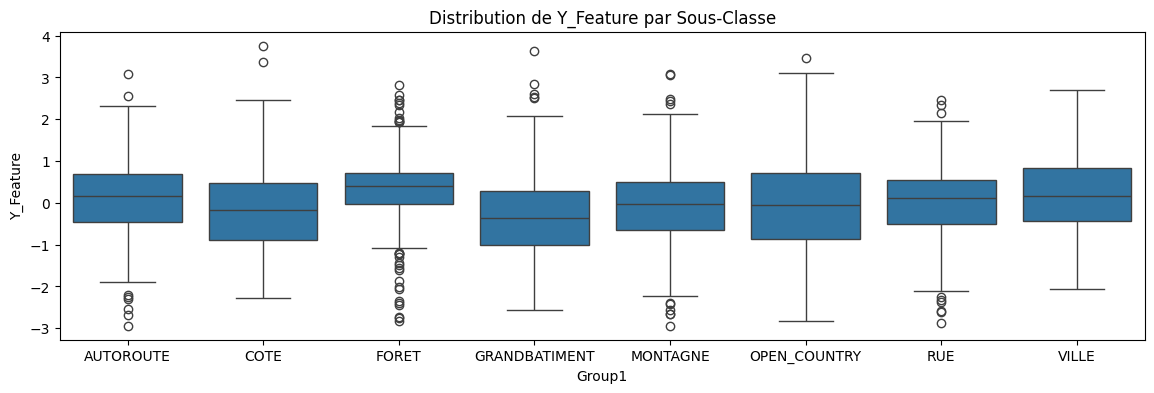

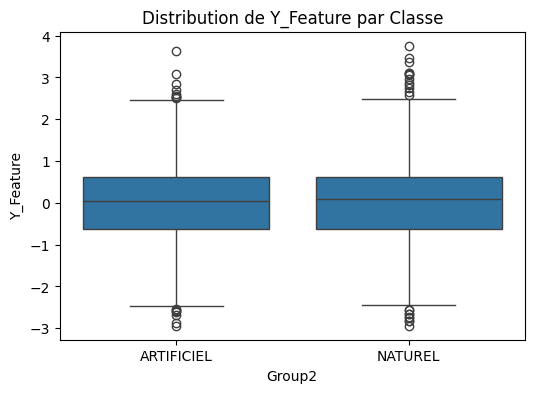

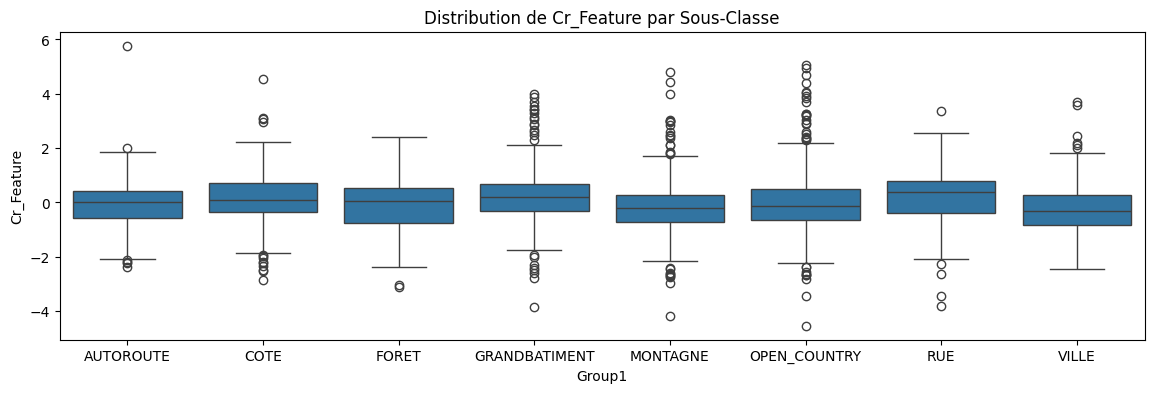

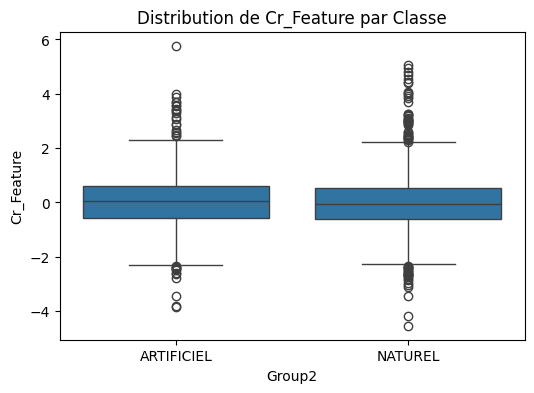

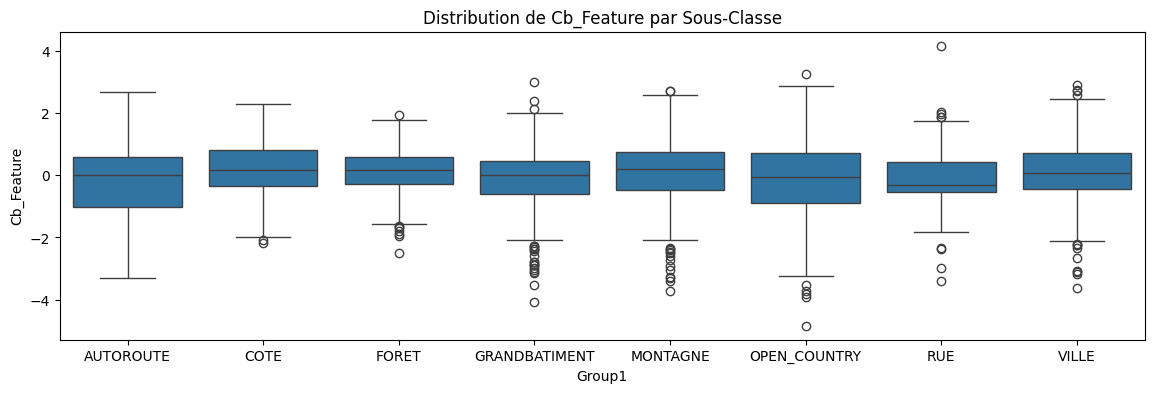

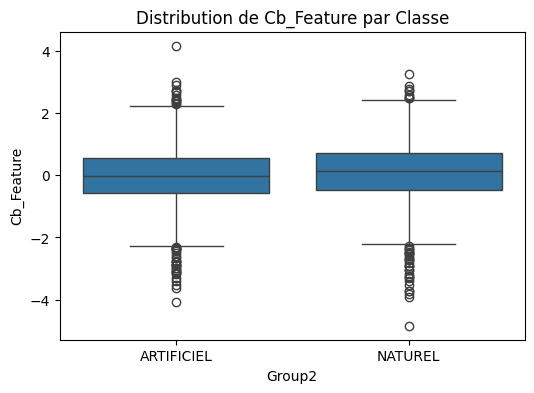

In [9]:
#Chaque boxplot seul et par classe et sous-classe
for column in Xdf_numeric:
    #Par sous-classes
    plt.figure(figsize=(14, 4)) 
    sns.boxplot(x="Group1", y=column, data=Xdf) 

    plt.title(f"Distribution de {column} par Sous-Classe")
    plt.show()

    #Par classes
    plt.figure(figsize=(6, 4)) 
    sns.boxplot(x="Group2", y=column, data=Xdf) 

    plt.title(f"Distribution de {column} par Classe")
    plt.show()

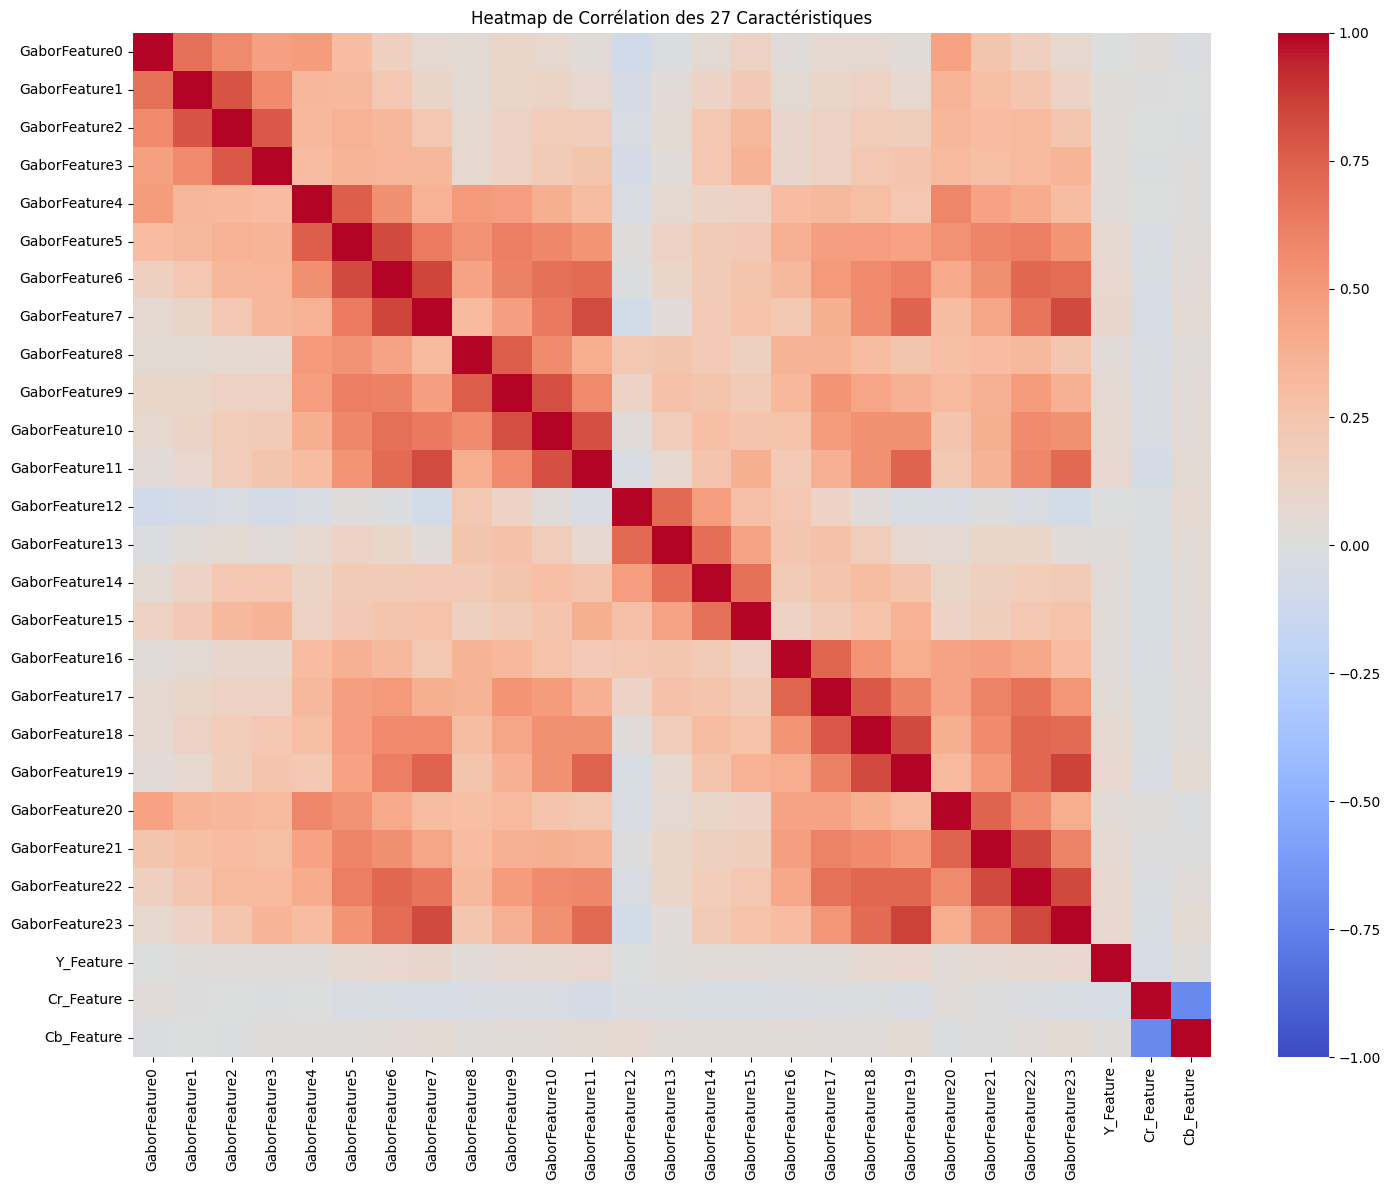

In [10]:
#On calcule les corrélation linéaire par couple de features
plt.figure(figsize=(15, 12))

sns.heatmap(
    Xdf_numeric.corr(),  
    annot=False,         
    cmap='coolwarm',     
    vmin=-1,             
    vmax=1               
)

plt.title('Heatmap de Corrélation des 27 Caractéristiques')
plt.tight_layout() 
plt.show()

On remarque que certaines (les plus proches) des 24 premières caractéristiques sont plutot très positivement corrélées entre elles et pour les 3 dernières seules Cr etCb son négativement corrélées

In [11]:
#On divise les données en données d'entrainement et de test
X_train_classe , X_test_classe, y_train_classe, y_test_classe = train_test_split(Xdf_numeric,y_classe,test_size=0.2,random_state=42)
X_train_sous_classe , X_test_sous_classe, y_train_sous_classe, y_test_sous_classe = train_test_split(Xdf_numeric,y_sous_classe,test_size=0.2,random_state=42)

In [12]:
#On va réaliser l'ACP et l'ALD sur chaque jeu de données de test
scaler = sc()
X_test_classe_scaled = scaler.fit_transform(X_test_sous_classe)
X_test_sous_classe_scaled = scaler.fit_transform(X_test_classe)

acp = PCA()

X_acp = acp.fit_transform(X_test_sous_classe_scaled,y_test_sous_classe)


27


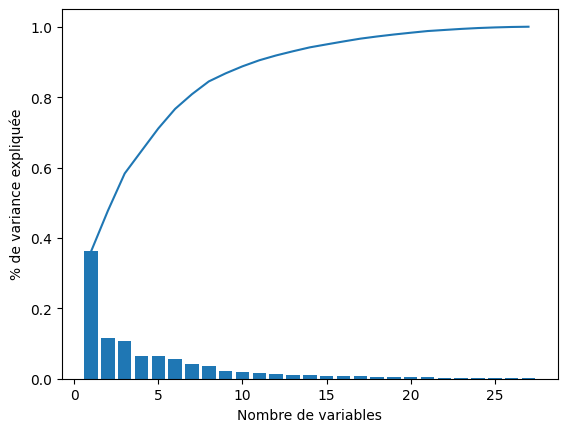

In [13]:
plt.figure() 
# Graphique du pouvoir de la variance expliquee
var_cum = [0]
for var in acp.explained_variance_ratio_:
    var_cum.append(var_cum[-1]+var)
var_cum.pop(0)
nb_axe_dis = len(X_acp[0])
print(nb_axe_dis)
plt.bar(np.arange(1, nb_axe_dis+1), acp.explained_variance_ratio_) 
plt.plot(np.arange(1,nb_axe_dis+1),var_cum)
plt.ylabel("% de variance expliquée") 
plt.xlabel("Nombre de variables") 
plt.show() 


ici 538


C:\Users\emman\AppData\Local\Temp\ipykernel_35376\215050132.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)
C:\Users\emman\AppData\Local\Temp\ipykernel_35376\215050132.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids_27d = df_27d.groupby('classe').mean().values


<Figure size 1600x1000 with 0 Axes>

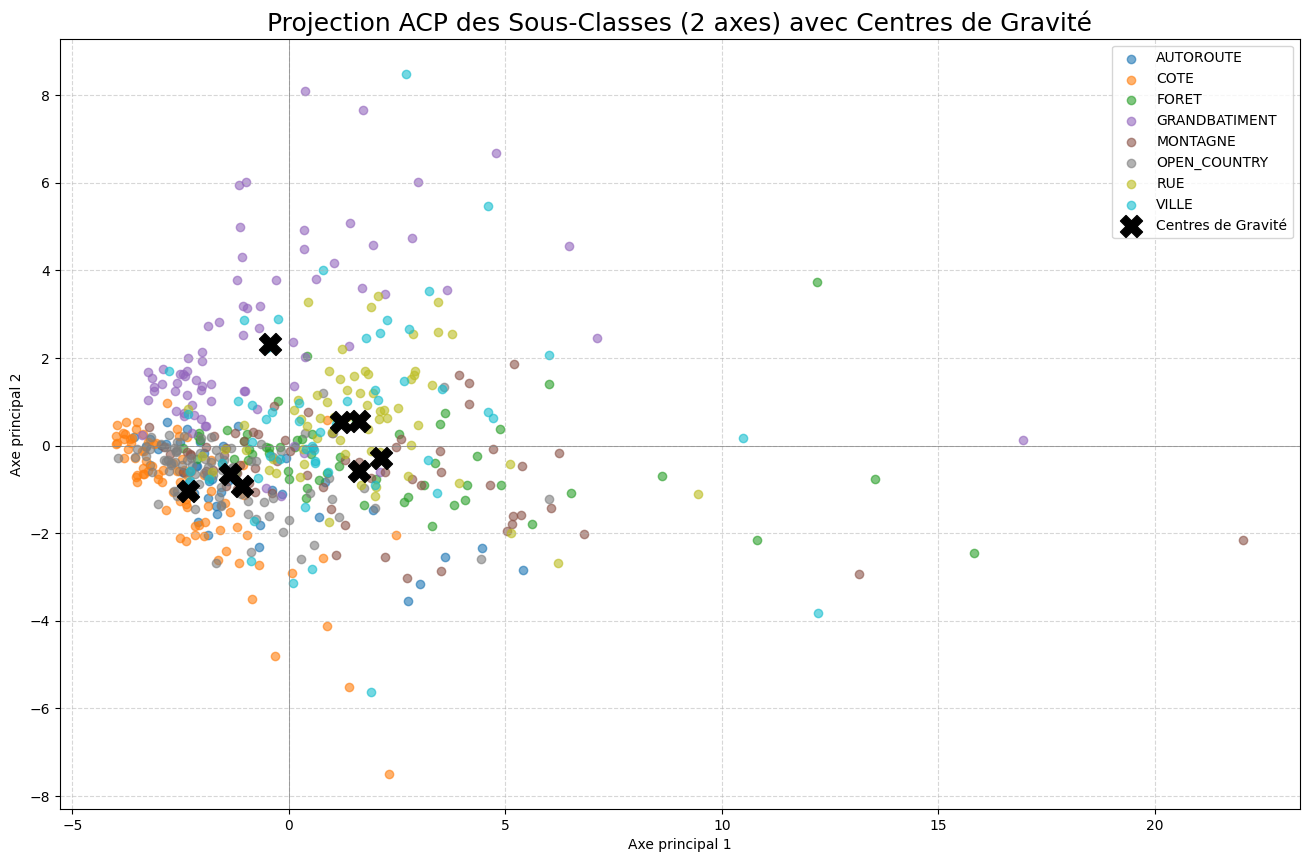

In [14]:
#projection sur les deux premiers axes et tracé du nuage de points

plt.figure(figsize=(16,10))
y_series = pd.Series(y_test_sous_classe).astype('category')
class_names = y_series.cat.categories
num_classes = len(class_names)

# Générer un jeu de couleurs distinctes
colors = plt.cm.get_cmap('tab10', num_classes)

# --- 2. Calcul des Centres de Gravité (Centroids) ---
# Mettez vos données 27D (avant ACP) et vos étiquettes dans un DataFrame
df_27d = pd.DataFrame(X_test_sous_classe_scaled) # REQUIERT X_train_scaled
print("ici",len(X_test_sous_classe_scaled))
df_27d['classe'] = y_series.values

# Calculer la moyenne (centre de gravité) en 27 dimensions
centroids_27d = df_27d.groupby('classe').mean().values

# Projeter ces centres 27D sur vos 2 axes ACP
# REQUIERT votre objet 'pca'
centroids_2d = acp.transform(centroids_27d) 

# --- 3. Création du Graphique ---
plt.figure(figsize=(16, 10))

# Boucle pour tracer chaque classe séparément (la clé pour la légende)
for i, class_name in enumerate(class_names):
    # Créer un masque pour ne sélectionner que les points de cette classe
    mask = (y_series == class_name)
    
    # Tracer les points de cette classe
    plt.scatter(
        X_acp[mask, 0],    # Coordonnées X des points de la classe
        X_acp[mask, 1],    # Coordonnées Y des points de la classe
        color=colors(i),   # Couleur spécifique pour cette classe
        label=class_name,  # Nom de la classe pour la légende
        alpha=0.6          # Transparence pour voir les superpositions
    )

# --- 4. Tracer les Centres de Gravité ---
plt.scatter(
    centroids_2d[:, 0], # Coordonnées X des centres
    centroids_2d[:, 1], # Coordonnées Y des centres
    marker='X',         # Marqueur en forme de 'X'
    c='black',          # Couleur noire
    s=250,              # Grande taille
    label='Centres de Gravité', # Étiquette pour la légende
    zorder=10           # 'zorder' pour s'assurer qu'ils sont au-dessus
)

# --- 5. Titre, Étiquettes et Légende ---
plt.title('Projection ACP des Sous-Classes (2 axes) avec Centres de Gravité', fontsize=18)
plt.xlabel('Axe principal 1') 
plt.ylabel('Axe principal 2') 
plt.legend(loc='best', markerscale=1.0) # Ajoute la légende
plt.grid(True, linestyle='--', alpha=0.5) # Ajoute une grille
plt.axhline(0, color='grey', linewidth=0.5) # Ligne à Y=0
plt.axvline(0, color='grey', linewidth=0.5) # Ligne à X=0

plt.show()

7


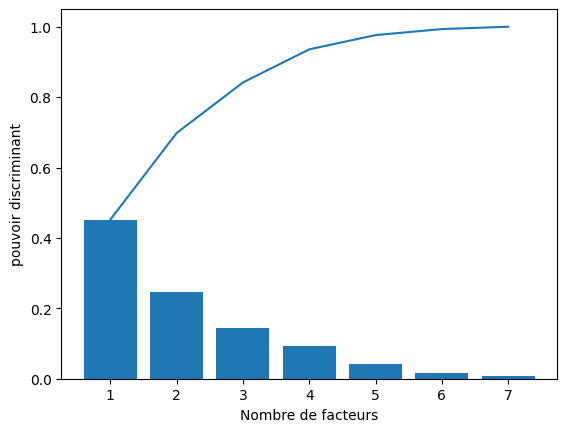

C:\Users\emman\AppData\Local\Temp\ipykernel_35376\1605029037.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)
C:\Users\emman\AppData\Local\Temp\ipykernel_35376\1605029037.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids_27d = df_27d.groupby('classe').mean().values


<Figure size 1600x1000 with 0 Axes>

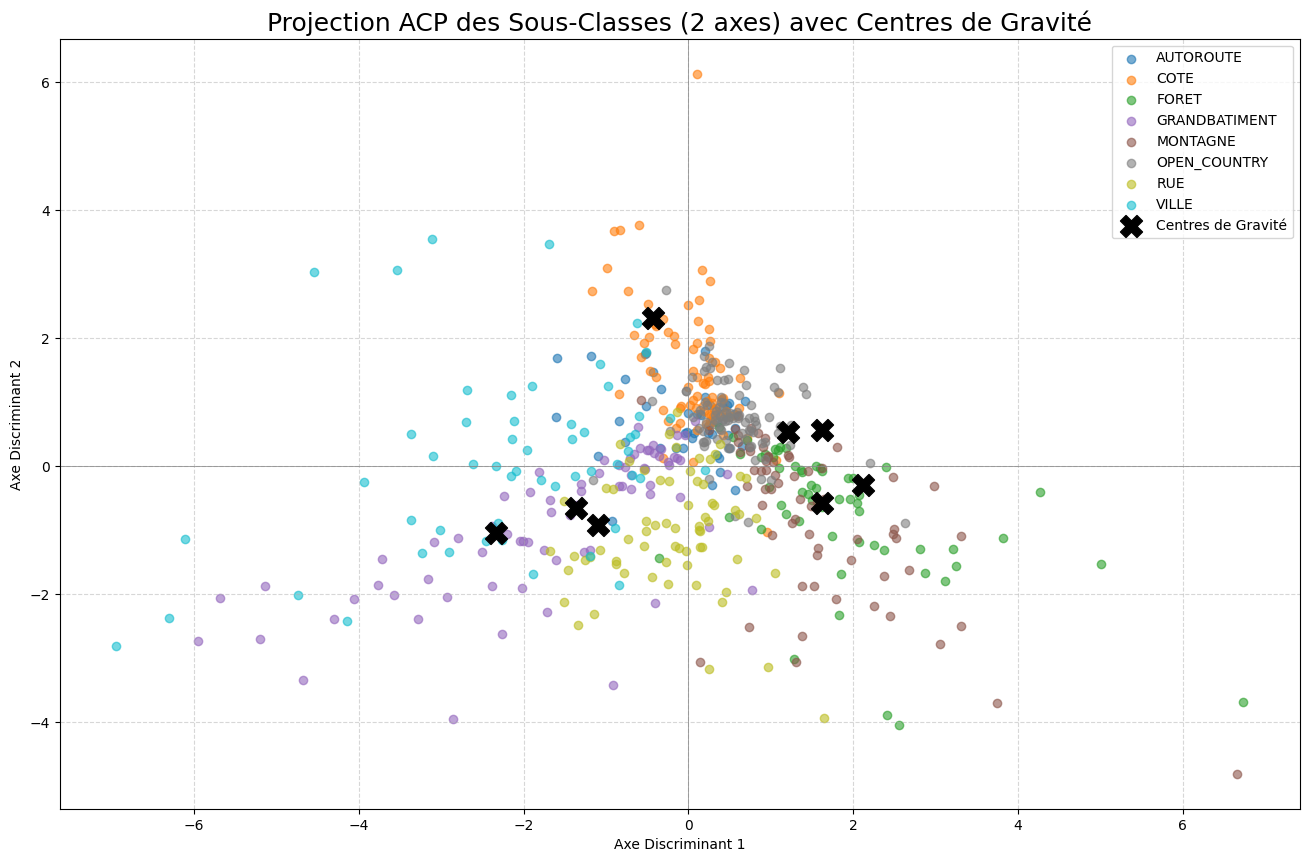

In [15]:
#On va réaliser une ALD par sous-classe
ald = LinearDiscriminantAnalysis()
X_ald = ald.fit_transform(X_test_sous_classe_scaled,y_test_sous_classe)

#Pouvoir dsicirminant
plt.figure() 
# Graphique du pouvoir discriminant de l'axe
nb_axe_dis = len(pd.Series(y_test_sous_classe).cat.categories)-1
print(nb_axe_dis)
var_cum = [0]
for var in ald.explained_variance_ratio_:
    var_cum.append(var_cum[-1]+var)
var_cum.pop(0)
nb_axe_dis = len(X_ald[0])
plt.bar(np.arange(1, nb_axe_dis+1), ald.explained_variance_ratio_) 
plt.plot(np.arange(1, nb_axe_dis+1), var_cum) 
plt.ylabel("pouvoir discriminant") 
plt.xlabel("Nombre de facteurs") 
plt.show()

#Trace des individu
plt.figure(figsize=(16,10))
y_series = pd.Series(y_test_sous_classe).astype('category')
class_names = y_series.cat.categories
num_classes = len(class_names)

# Générer un jeu de couleurs distinctes
colors = plt.cm.get_cmap('tab10', num_classes)

# --- 2. Calcul des Centres de Gravité (Centroids) ---
# Mettez vos données 27D (avant ACP) et vos étiquettes dans un DataFrame
df_27d = pd.DataFrame(X_test_sous_classe_scaled) # REQUIERT X_train_scaled
df_27d['classe'] = y_series.values

# Calculer la moyenne (centre de gravité) en 27 dimensions
centroids_27d = df_27d.groupby('classe').mean().values

# Projeter ces centres 27D sur vos 2 axes ACP
# REQUIERT votre objet 'pca'
centroids_2d = acp.transform(centroids_27d) 

# --- 3. Création du Graphique ---
plt.figure(figsize=(16, 10))

# Boucle pour tracer chaque classe séparément (la clé pour la légende)
for i, class_name in enumerate(class_names):
    # Créer un masque pour ne sélectionner que les points de cette classe
    mask = (y_series == class_name)
    
    # Tracer les points de cette classe
    plt.scatter(
        X_ald[mask, 0],    # Coordonnées X des points de la classe
        X_ald[mask, 1],    # Coordonnées Y des points de la classe
        color=colors(i),   # Couleur spécifique pour cette classe
        label=class_name,  # Nom de la classe pour la légende
        alpha=0.6          # Transparence pour voir les superpositions
    )

# --- 4. Tracer les Centres de Gravité ---
plt.scatter(
    centroids_2d[:, 0], # Coordonnées X des centres
    centroids_2d[:, 1], # Coordonnées Y des centres
    marker='X',         # Marqueur en forme de 'X'
    c='black',          # Couleur noire
    s=250,              # Grande taille
    label='Centres de Gravité', # Étiquette pour la légende
    zorder=10           # 'zorder' pour s'assurer qu'ils sont au-dessus
)

# --- 5. Titre, Étiquettes et Légende ---
plt.title('Projection ACP des Sous-Classes (2 axes) avec Centres de Gravité', fontsize=18)
plt.xlabel('Axe Discriminant 1') 
plt.ylabel('Axe Discriminant 2') 
plt.legend(loc='best', markerscale=1.0) # Ajoute la légende
plt.grid(True, linestyle='--', alpha=0.5) # Ajoute une grille
plt.axhline(0, color='grey', linewidth=0.5) # Ligne à Y=0
plt.axvline(0, color='grey', linewidth=0.5) # Ligne à X=0

plt.show()



1


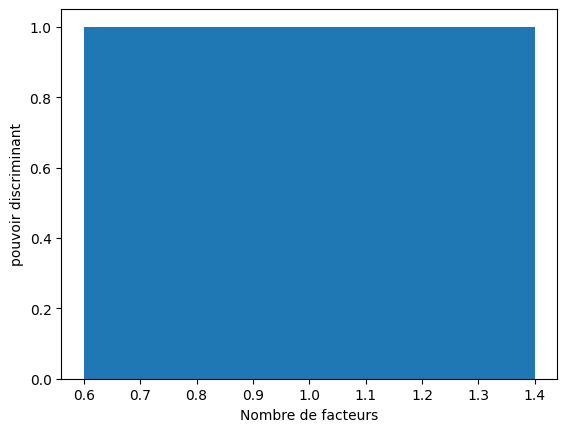

C:\Users\emman\AppData\Local\Temp\ipykernel_35376\1510194182.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)
C:\Users\emman\AppData\Local\Temp\ipykernel_35376\1510194182.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids_27d = df_27d.groupby('classe').mean().values


<Figure size 1600x1000 with 0 Axes>

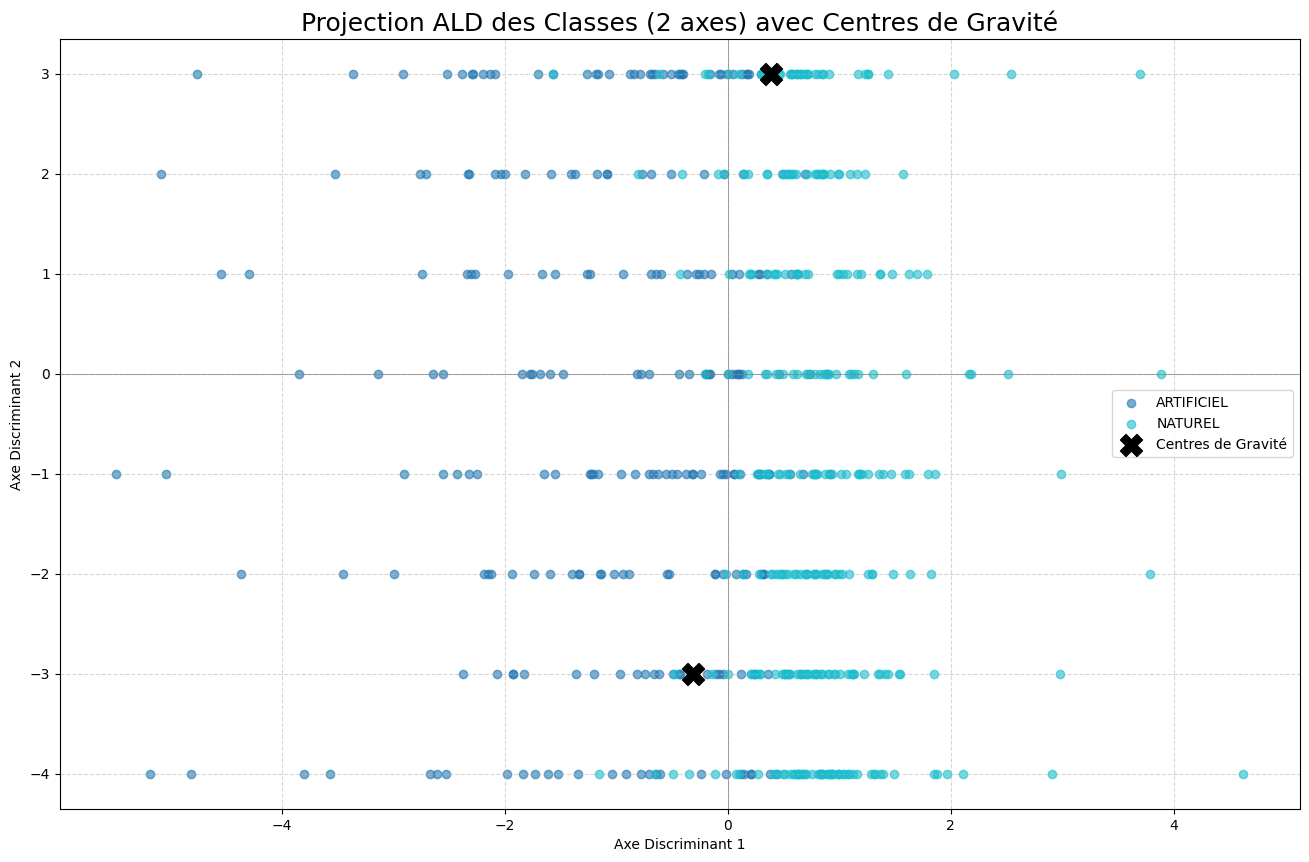

In [16]:
#On va réaliser une ALD par Classes
ald = LinearDiscriminantAnalysis()
X_ald = ald.fit_transform(X_test_sous_classe_scaled,y_test_classe)

#Pouvoir dsicirminant
plt.figure() 
# Graphique du pouvoir discriminant de l'axe
nb_axe_dis = len(pd.Series(y_train_classe).cat.categories)-1
print(nb_axe_dis)
var_cum = [0]
for var in ald.explained_variance_ratio_:
    var_cum.append(var_cum[-1]+var)
var_cum.pop(0)
nb_axe_dis = len(X_ald[0])
plt.bar(np.arange(1, nb_axe_dis+1), ald.explained_variance_ratio_) 
plt.plot(np.arange(1, nb_axe_dis+1), var_cum) 
plt.ylabel("pouvoir discriminant") 
plt.xlabel("Nombre de facteurs") 
plt.show()

#Trace des individu
plt.figure(figsize=(16,10))
y_series = pd.Series(y_test_classe).astype('category')
class_names = y_series.cat.categories
num_classes = len(class_names)

# Générer un jeu de couleurs distinctes
colors = plt.cm.get_cmap('tab10', num_classes)

# --- 2. Calcul des Centres de Gravité (Centroids) ---
# Mettez vos données 27D (avant ACP) et vos étiquettes dans un DataFrame
df_27d = pd.DataFrame(X_test_sous_classe_scaled) # REQUIERT X_train_scaled
df_27d['classe'] = y_series.values

# Calculer la moyenne (centre de gravité) en 27 dimensions
centroids_27d = df_27d.groupby('classe').mean().values

# Projeter ces centres 27D sur vos 2 axes ACP
# REQUIERT votre objet 'pca'
centroids_2d = acp.transform(centroids_27d) 

# --- 3. Création du Graphique ---
plt.figure(figsize=(16, 10))

# Boucle pour tracer chaque classe séparément (la clé pour la légende)
for i, class_name in enumerate(class_names):
    # Créer un masque pour ne sélectionner que les points de cette classe
    mask = (y_series == class_name)
    
    # Tracer les points de cette classe
    plt.scatter(
        X_ald[mask, 0],    # Coordonnées X des points de la classe
        np.random.randint(-4,4,len(X_ald[mask, 0])),    # Coordonnées Y des points de la classe
        color=colors(i),   # Couleur spécifique pour cette classe
        label=class_name,  # Nom de la classe pour la légende
        alpha=0.6          # Transparence pour voir les superpositions
    )

# --- 4. Tracer les Centres de Gravité ---
plt.scatter(
    centroids_2d[:, 0], # Coordonnées X des centres
    np.random.randint(-4,4,len(centroids_2d[:, 0])), # Coordonnées Y des centres
    marker='X',         # Marqueur en forme de 'X'
    c='black',          # Couleur noire
    s=250,              # Grande taille
    label='Centres de Gravité', # Étiquette pour la légende
    zorder=10           # 'zorder' pour s'assurer qu'ils sont au-dessus
)

# --- 5. Titre, Étiquettes et Légende ---
plt.title('Projection ALD des Classes (2 axes) avec Centres de Gravité', fontsize=18)
plt.xlabel('Axe Discriminant 1') 
plt.ylabel('Axe Discriminant 2') 
plt.legend(loc='best', markerscale=1.0) # Ajoute la légende
plt.grid(True, linestyle='--', alpha=0.5) # Ajoute une grille
plt.axhline(0, color='grey', linewidth=0.5) # Ligne à Y=0
plt.axvline(0, color='grey', linewidth=0.5) # Ligne à X=0

plt.show()



#### 2e Partie : 

In [20]:
#On va mettre en place un classifieur basé sur le MLP
#On va faire une validation croisée pour fixer la structure du MLPC
mlpc = MLPC(max_iter=100)
params = {"hidden_layer_sizes":[10,20,30,40,50,60,70,80,90,100],"activation":('identity','logistic','tanh','relu')}

gridSearchClassifier = GridSearchCV(mlpc,params)
scores = cross_val_score(gridSearchClassifier, X_train_sous_classe, y_train_sous_classe, cv = 5)


c:\Users\emman\OneDrive\Desktop\IESE 5\Machine Learning\projet2\.env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\emman\OneDrive\Desktop\IESE 5\Machine Learning\projet2\.env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\emman\OneDrive\Desktop\IESE 5\Machine Learning\projet2\.env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\emman\OneDrive\Desktop\IESE 5\Machine Learning\projet2\.env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic 